In [12]:
!pip install qiskit qiskit-aer qiskit-nature qiskit-algorithms pyscf matplotlib pandas --quiet

In [13]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eigh

from qiskit import transpile
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit.library import efficient_su2
from qiskit.circuit.library import real_amplitudes

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper, ParityMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver, QEOM
from qiskit_nature.second_q.operators import FermionicOp

from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import SLSQP, COBYLA

from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit_aer.primitives import EstimatorV2 as AerEstimatorV2, SamplerV2 as AerSamplerV2

from qiskit.quantum_info import Statevector

HARTREE_TO_EV = 27.211386245988
EXPERIMENTAL_PI_PISTAR_EV = 7.6
np.random.seed(1)

## Part 1:  **Molecular setup**

In [14]:
def rotate_z(xyz, angle_deg):
    a = np.radians(angle_deg)
    R = np.array([[np.cos(a), -np.sin(a), 0],
                  [np.sin(a),  np.cos(a), 0],
                  [0, 0, 1]])
    return R @ np.array(xyz)

def build_geometry(twist_deg: float = 0.0) -> str:
    atoms = {k: v.copy() for k, v in equilibrium_atoms.items()}
    if twist_deg != 0.0:
        atoms["H3"] = rotate_z(atoms["H3"], twist_deg)
        atoms["H4"] = rotate_z(atoms["H4"], twist_deg)
    order = ["C1", "C2", "H1", "H2", "H3", "H4"]
    return "; ".join(f"{name[0]} {x:.6f} {y:.6f} {z:.6f}" for name in order
                      for x, y, z in [atoms[name]])

def print_geometry(label, geometry):
    print(f"{label}:")
    atoms = geometry.split("; ")
    for i, atom in enumerate(atoms):
        suffix = ";" if i < len(atoms) - 1 else ""
        print(f"  {atom}{suffix}")

# Standard planar equilibrium ethylene geometry (Angstrom)
equilibrium_atoms = {
    "C1": np.array([0.0000,  0.0000,  0.6695]),
    "C2": np.array([0.0000,  0.0000, -0.6695]),
    "H1": np.array([0.0000,  0.9289,  1.2321]),
    "H2": np.array([0.0000, -0.9289,  1.2321]),
    "H3": np.array([0.0000,  0.9289, -1.2321]),
    "H4": np.array([0.0000, -0.9289, -1.2321]),
}


geometry_equilibrium = build_geometry(0.0)
geometry_twisted = build_geometry(90.0)

# print(geometry_equilibrium)
print_geometry("Equilibrium", geometry_equilibrium)
print_geometry("\nTwisted 90", geometry_twisted)

Equilibrium:
  C 0.000000 0.000000 0.669500;
  C 0.000000 0.000000 -0.669500;
  H 0.000000 0.928900 1.232100;
  H 0.000000 -0.928900 1.232100;
  H 0.000000 0.928900 -1.232100;
  H 0.000000 -0.928900 -1.232100

Twisted 90:
  C 0.000000 0.000000 0.669500;
  C 0.000000 0.000000 -0.669500;
  H 0.000000 0.928900 1.232100;
  H 0.000000 -0.928900 1.232100;
  H -0.928900 0.000000 -1.232100;
  H 0.928900 -0.000000 -1.232100


In [15]:
driver = PySCFDriver(atom=geometry_equilibrium, basis="sto3g", charge=0, spin=0)
full_eq = driver.run()
print(f"Full STO-3G problem: {full_eq.num_spatial_orbitals} spatial orbitals, {full_eq.num_particles} particles")
print(f"Restricted Hartree-Fock (RHF) reference energy: {full_eq.reference_energy:.6f} Ha")
print(f"Nuclear repulsion energy: {full_eq.hamiltonian.nuclear_repulsion_energy:.6f} Ha")

Full STO-3G problem: 14 spatial orbitals, (8, 8) particles
Restricted Hartree-Fock (RHF) reference energy: -77.072088 Ha
Nuclear repulsion energy: 33.265090 Ha


In [16]:
# Active space: 2 electrons in 2 spatial orbitals (the pi / pi* frontier orbitals).

def ActiveSpaceTransformation(full_problem, num_active_electrons, num_spatial_orbitals):
  as_transformer = ActiveSpaceTransformer(num_electrons=num_active_electrons, num_spatial_orbitals=num_spatial_orbitals)
  as_eq = as_transformer.transform(full_problem)
  print(f"Active-space problem: {as_eq.num_spatial_orbitals} spatial orbitals, "
        f"{as_eq.num_particles} particles")
  print(f"Energy offset absorbed into the classical core (frozen-core + nuclear repulsion): {sum(as_eq.hamiltonian.constants.values()):.6f} Ha")
  return as_eq

# 2 electrons/2 orbitals
active_space_eq = ActiveSpaceTransformation(full_eq, 2, 2)


Active-space problem: 2 spatial orbitals, (1, 1) particles
Energy offset absorbed into the classical core (frozen-core + nuclear repulsion): -75.918420 Ha


In [17]:
# Qubit mapping: Jordan-Wigner vs. Parity mapping + two-qubit tapering
hamiltonian_op = active_space_eq.hamiltonian.second_q_op()

jw_mapper = JordanWignerMapper()
qubit_op_jw = jw_mapper.map(hamiltonian_op)

parity_mapper = ParityMapper(num_particles=active_space_eq.num_particles)
qubit_op_parity = parity_mapper.map(hamiltonian_op)

print(f"Jordan-Wigner mapping : {qubit_op_jw.num_qubits} qubits")
print(f"Parity mapping with tapering (2-qubit reduction) : {qubit_op_parity.num_qubits} qubits")

mapper = jw_mapper

Jordan-Wigner mapping : 4 qubits
Parity mapping with tapering (2-qubit reduction) : 2 qubits


## Part 2:  **Ground-state VQE**
We implement two ansätze on top of the Hartree-Fock reference state:

- UCCSD
- Hardware-efficient ansatz (HEA): we will try EfficientSU2 and RealAmplitudes

In [18]:
hf_state = HartreeFock(active_space_eq.num_spatial_orbitals, active_space_eq.num_particles, mapper)

uccsd_ansatz = UCCSD(active_space_eq.num_spatial_orbitals, active_space_eq.num_particles, mapper, initial_state=hf_state)

hea_core = efficient_su2(qubit_op_jw.num_qubits, reps=2, entanglement="linear")
hea_ansatz = hf_state.compose(hea_core)

rea_core = real_amplitudes(qubit_op_jw.num_qubits, reps=2, entanglement="linear")
rea_ansatz = hf_state.compose(rea_core)

ansatz_stats = pd.DataFrame([
    {"Ansatz": "UCCSD", "Qubits": uccsd_ansatz.num_qubits,
     "Parameters": uccsd_ansatz.num_parameters,
     "Depth (decomposed)": uccsd_ansatz.decompose(reps=3).depth()},
    {"Ansatz": "Hardware-efficient (EfficientSU2, reps=2)", "Qubits": hea_ansatz.num_qubits,
     "Parameters": hea_ansatz.num_parameters,
     "Depth (decomposed)": hea_ansatz.decompose(reps=2).depth()},
    {"Ansatz": "Hardware-efficient (RealAmplitudes, reps=2)", "Qubits": rea_ansatz.num_qubits,
     "Parameters": rea_ansatz.num_parameters,
     "Depth (decomposed)": rea_ansatz.decompose(reps=2).depth()},
])
ansatz_stats

,Ansatz,Qubits,Parameters,Depth (decomposed)
0,UCCSD,4,3,112
1,"Hardware-efficient (EfficientSU2, reps=2)",4,24,12
2,"Hardware-efficient (RealAmplitudes, reps=2)",4,12,9


In [19]:
def run_vqe(ansatz, problem, mapper, optimizer, initial_point=None, estimator=None):
    '''Run VQE (statevector, noise-free by default) and return (result, history).'''
    estimator = estimator or StatevectorEstimator()
    history = []
    def callback(eval_count, params, value, meta):
        history.append(value)
    vqe = VQE(estimator, ansatz, optimizer, callback=callback)
    vqe.initial_point = (initial_point if initial_point is not None
                          else np.zeros(ansatz.num_parameters))
    solver = GroundStateEigensolver(mapper, vqe)
    result = solver.solve(problem)
    return result, history, vqe

result_uccsd, history_uccsd, vqe_uccsd = run_vqe(
    uccsd_ansatz, active_space_eq, mapper, SLSQP(maxiter=200))

rng = np.random.default_rng(1)
result_hea, history_hea, vqe_hea = run_vqe(
    hea_ansatz, active_space_eq, mapper, COBYLA(maxiter=300),
    initial_point=rng.uniform(-0.1, 0.1, hea_ansatz.num_parameters))

rng2 = np.random.default_rng(1)
result_rea, history_rea, vqe_rea = run_vqe(
    rea_ansatz, active_space_eq, mapper, COBYLA(maxiter=300),
    initial_point=rng2.uniform(-0.1, 0.1, rea_ansatz.num_parameters))

exact_result = GroundStateEigensolver(mapper, NumPyMinimumEigensolver()).solve(active_space_eq)
exact_energy_eq = exact_result.total_energies[0]

print(f"Exact (full CI in active space) ground energy : {exact_energy_eq:.8f} Ha")
print(f"VQE UCCSD ground energy                       : {result_uccsd.total_energies[0]:.8f} Ha "
      f"(Δ = {(result_uccsd.total_energies[0]-exact_energy_eq)*1000:.4f} mHa)")
print(f"VQE hardware-efficient ansatz ground energy   : {result_hea.total_energies[0]:.8f} Ha "
      f"(Δ = {(result_hea.total_energies[0]-exact_energy_eq)*1000:.4f} mHa)")
print(f"VQE RealAmplitudes ground energy              : {result_rea.total_energies[0]:.8f} Ha "
      f"(Δ = {(result_rea.total_energies[0]-exact_energy_eq)*1000:.4f} mHa)")

Exact (full CI in active space) ground energy : -77.11659291 Ha
VQE UCCSD ground energy                       : -77.11659291 Ha (Δ = 0.0000 mHa)
VQE hardware-efficient ansatz ground energy   : -77.11640764 Ha (Δ = 0.1853 mHa)
VQE RealAmplitudes ground energy              : -77.11648733 Ha (Δ = 0.1056 mHa)


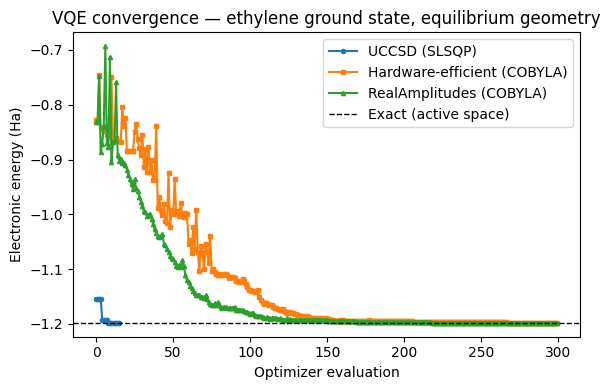

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_uccsd, label="UCCSD (SLSQP)", marker="o", ms=3)
ax.plot(history_hea, label="Hardware-efficient (COBYLA)", marker="s", ms=3)
ax.plot(history_rea, label="RealAmplitudes (COBYLA)", marker="^", ms=3)
ax.axhline(exact_result.eigenvalues[0], color="k", ls="--", lw=1, label="Exact (active space)")
ax.set_xlabel("Optimizer evaluation")
ax.set_ylabel("Electronic energy (Ha)")
ax.set_title("VQE convergence — ethylene ground state, equilibrium geometry")
ax.legend()
plt.tight_layout()
plt.show()

## Part 3:  **Excited states via QSE**

In [21]:
def build_excitation_ops(num_spatial_orbitals, num_particles):
    """Single + double excitation operators (alpha/beta) for the active space."""
    n_so = 2 * num_spatial_orbitals
    n_occ_a, n_occ_b = num_particles
    occ_a = list(range(n_occ_a))
    occ_b = list(range(num_spatial_orbitals, num_spatial_orbitals + n_occ_b))
    vir_a = list(range(n_occ_a, num_spatial_orbitals))
    vir_b = list(range(num_spatial_orbitals + n_occ_b, n_so))

    ops = []
    for i in occ_a:                       # alpha singles
        for a in vir_a:
            ops.append(FermionicOp({f"+_{a} -_{i}": 1.0}, num_spin_orbitals=n_so))
    for i in occ_b:                       # beta singles
        for a in vir_b:
            ops.append(FermionicOp({f"+_{a} -_{i}": 1.0}, num_spin_orbitals=n_so))
    for i in occ_a:                       # alpha-beta doubles
        for j in occ_b:
            for a in vir_a:
                for b in vir_b:
                    ops.append(FermionicOp({f"+_{a} +_{b} -_{j} -_{i}": 1.0}, num_spin_orbitals=n_so))
    return ops

def run_qse(ground_state_solver, problem, mapper):
    # 1. Solve VQE, get the ground-state statevector
    gs_result = ground_state_solver.solve(problem)
    optimal_circuit = gs_result.raw_result.optimal_circuit.assign_parameters(
        gs_result.raw_result.optimal_point
    )
    psi0 = Statevector(optimal_circuit).data

    # 2. Hamiltonian as a dense matrix
    H = mapper.map(problem.hamiltonian.second_q_op()).to_matrix()

    # 3. Build the subspace {|psi0>, E_i|psi0>} for each excitation operator
    fermionic_ops = build_excitation_ops(problem.num_spatial_orbitals, problem.num_particles)
    op_matrices = [np.eye(H.shape[0])] + [mapper.map(op).to_matrix() for op in fermionic_ops]
    subspace_states = [op @ psi0 for op in op_matrices]

    # 4. Solve the generalized eigenvalue problem  H C = E S C
    n = len(subspace_states)
    H_sub = np.zeros((n, n), dtype=complex)
    S_sub = np.zeros((n, n), dtype=complex)
    for i in range(n):
        for j in range(n):
            H_sub[i, j] = np.vdot(subspace_states[i], H @ subspace_states[j])
            S_sub[i, j] = np.vdot(subspace_states[i], subspace_states[j])

    return eigh(H_sub, S_sub, eigvals_only=True)

gse_uccsd = GroundStateEigensolver(mapper, vqe_uccsd)
qse_energies_eq = run_qse(gse_uccsd, active_space_eq, mapper)
excitation_eq_eV_qse = (qse_energies_eq - qse_energies_eq[0]) * HARTREE_TO_EV

print("QSE ground and excited electronic energies (Ha):", np.round(qse_energies_eq, 6))
print("QSE excitation energies relative to the ground state (eV):", np.round(excitation_eq_eV_qse, 4))
print(f"\nQSE computed vertical pi -> pi* excitation energy : {excitation_eq_eV_qse[1]:.3f} eV")
print(f"Experimental reference : {EXPERIMENTAL_PI_PISTAR_EV} eV")
print(f"Difference : {excitation_eq_eV_qse[1]-EXPERIMENTAL_PI_PISTAR_EV:+.3f} eV")

QSE ground and excited electronic energies (Ha): [-1.198173 -1.022076 -0.678003 -0.488654]
QSE excitation energies relative to the ground state (eV): [ 0.      4.7918 14.1545 19.307 ]

QSE computed vertical pi -> pi* excitation energy : 4.792 eV
Experimental reference : 7.6 eV
Difference : -2.808 eV
